In [ ]:
    from google.colab import files

uploaded = files.upload()

Saving Data set (1).zip to Data set (1).zip


In [ ]:
!mkdir -p data
!unzip "Data set (1).zip" -d data

Streaming output truncated to the last 5000 lines.
  inflating: data/lungnodulenewimagedataset/train_set/non nodule/image_172243 (2).jpg  
  inflating: data/lungnodulenewimagedataset/train_set/non nodule/image_172244 (2).jpg  
  inflating: data/lungnodulenewimagedataset/train_set/non nodule/image_17228 (2).jpg  
  inflating: data/lungnodulenewimagedataset/train_set/non nodule/image_172283 (2).jpg  
  inflating: data/lungnodulenewimagedataset/train_set/non nodule/image_172424 (2).jpg  
  inflating: data/lungnodulenewimagedataset/train_set/non nodule/image_172524 (2).jpg  
  inflating: data/lungnodulenewimagedataset/train_set/non nodule/image_172561 (2).jpg  
  inflating: data/lungnodulenewimagedataset/train_set/non nodule/image_172655 (2).jpg  
  inflating: data/lungnodulenewimagedataset/train_set/non nodule/image_172748 (2).jpg  
  inflating: data/lungnodulenewimagedataset/train_set/non nodule/image_172789 (2).jpg  
  inflating: data/lungnodulenewimagedataset/train_set/non nodule/image

In [ ]:
!find data -maxdepth 3 -type d


data
data/lungnodulenewimagedataset
data/lungnodulenewimagedataset/validation_set
data/lungnodulenewimagedataset/validation_set/nodule
data/lungnodulenewimagedataset/validation_set/non nodule
data/lungnodulenewimagedataset/test_set
data/lungnodulenewimagedataset/test_set/nodule
data/lungnodulenewimagedataset/test_set/non nodule
data/lungnodulenewimagedataset/train_set
data/lungnodulenewimagedataset/train_set/nodule
data/lungnodulenewimagedataset/train_set/non nodule


In [ ]:
import os
import gc
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

gc.collect()
tf.keras.backend.clear_session()

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
GPU: []


In [ ]:
DATASET_ROOT = "data/lungnodulenewimagedataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train_set")
VAL_DIR   = os.path.join(DATASET_ROOT, "validation_set")
TEST_DIR  = os.path.join(DATASET_ROOT, "test_set")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Val exists  :", os.path.exists(VAL_DIR))
print("Test exists :", os.path.exists(TEST_DIR))


Train exists: True
Val exists  : True
Test exists : True


In [ ]:
CLASSES = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

NUM_CLASSES = len(CLASSES)
print("Detected classes:", CLASSES)


Detected classes: ['nodule', 'non nodule']


In [ ]:
IMG_SIZE = 160
BATCH_SIZE = 8
EPOCHS = 10


In [ ]:
def preprocess_image_tf(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


In [ ]:
def build_paths(split_dir):
    paths, labels = [], []
    for idx, cls in enumerate(CLASSES):
        cls_dir = os.path.join(split_dir, cls)
        for img in os.listdir(cls_dir):
            paths.append(os.path.join(cls_dir, img))
            labels.append(idx)
    return paths, labels


In [ ]:
def create_dataset(paths, labels, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(1000)

    ds = ds.map(
        lambda x, y: preprocess_image_tf(
            x, tf.one_hot(y, NUM_CLASSES)
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


In [ ]:
train_p, train_l = build_paths(TRAIN_DIR)
val_p, val_l     = build_paths(VAL_DIR)
test_p, test_l   = build_paths(TEST_DIR)

train_ds = create_dataset(train_p, train_l, shuffle=True)
val_ds   = create_dataset(val_p, val_l, shuffle=False)
test_ds  = create_dataset(test_p, test_l, shuffle=False)

print("Datasets ready — safe to train")


Datasets ready — safe to train


In [ ]:
from tensorflow.keras import layers

def LGAM(x):
    # Spatial attention using pooling layers (Keras-native)
    avg_pool = layers.GlobalAveragePooling2D(keepdims=True)(x)
    max_pool = layers.GlobalMaxPooling2D(keepdims=True)(x)

    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    attention = layers.Conv2D(
        filters=1,
        kernel_size=1,
        activation='sigmoid',
        padding='same'
    )(concat)

    return layers.Multiply()([x, attention])


In [ ]:
from tensorflow.keras import layers, models

def Lung_AttNet():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(32, 3, activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = LGAM(x)   # ← now SAFE

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Nadam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
model = Lung_AttNet()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
649/649 ━━━━━━━━━━━━━━━━━━━━ 292s 444ms/step - accuracy: 0.7699 - loss: 0.5238 - val_accuracy: 0.8260 - val_loss: 0.7896
Epoch 2/10
649/649 ━━━━━━━━━━━━━━━━━━━━ 313s 432ms/step - accuracy: 0.7592 - loss: 0.5351 - val_accuracy: 0.8267 - val_loss: 0.5133
Epoch 3/10
649/649 ━━━━━━━━━━━━━━━━━━━━ 277s 427ms/step - accuracy: 0.8172 - loss: 0.4078 - val_accuracy: 0.8454 - val_loss: 0.4169
Epoch 4/10
649/649 ━━━━━━━━━━━━━━━━━━━━ 286s 440ms/step - accuracy: 0.8611 - loss: 0.3204 - val_accuracy: 0.8563 - val_loss: 0.4564
Epoch 5/10
649/649 ━━━━━━━━━━━━━━━━━━━━ 333s 457ms/step - accuracy: 0.8893 - loss: 0.2627 - val_accuracy: 0.8578 - val_loss: 0.4557
Epoch 6/10
649/649 ━━━━━━━━━━━━━━━━━━━━ 287s 443ms/step - accuracy: 0.9167 - loss: 0.2137 - val_accuracy: 0.8695 - val_loss: 0.4256
Epoch 7/10
649/649 ━━━━━━━━━━━━━━━━━━━━ 290s 447ms/step - accuracy: 0.9355 - loss: 0.1673 - val_accuracy: 0.8656 - val_loss: 0.4840
Epoch 8/10
649/649 ━━━━━━━━━━━━━━━━━━━━ 311s 431ms/step - accuracy: 0.9459 -

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
649/649 ━━━━━━━━━━━━━━━━━━━━ 298s 459ms/step - accuracy: 0.9799 - loss: 0.0510 - val_accuracy: 0.8889 - val_loss: 0.5512
Epoch 2/20
649/649 ━━━━━━━━━━━━━━━━━━━━ 281s 433ms/step - accuracy: 0.9873 - loss: 0.0369 - val_accuracy: 0.8827 - val_loss: 0.7020
Epoch 3/20
649/649 ━━━━━━━━━━━━━━━━━━━━ 283s 437ms/step - accuracy: 0.9836 - loss: 0.0413 - val_accuracy: 0.8819 - val_loss: 0.6308
Epoch 4/20
649/649 ━━━━━━━━━━━━━━━━━━━━ 285s 439ms/step - accuracy: 0.9845 - loss: 0.0433 - val_accuracy: 0.8881 - val_loss: 0.7651


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

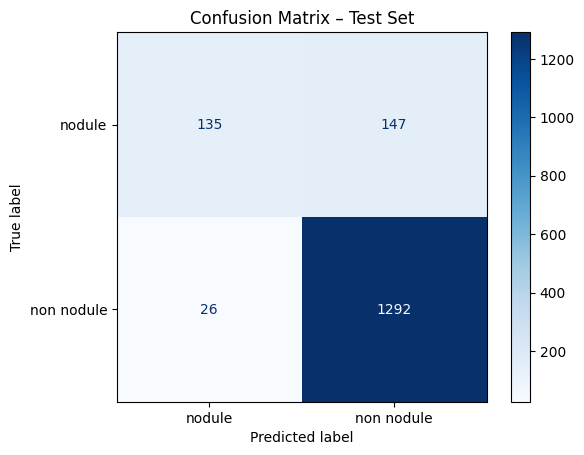

              precision    recall  f1-score   support

      nodule       0.84      0.48      0.61       282
  non nodule       0.90      0.98      0.94      1318

    accuracy                           0.89      1600
   macro avg       0.87      0.73      0.77      1600
weighted avg       0.89      0.89      0.88      1600



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

y_true, y_pred = [], []

for x, y in test_ds:
    preds = model.predict(x)
    y_true.extend(tf.argmax(y, axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=CLASSES,
    cmap="Blues"
)
plt.title("Confusion Matrix – Test Set")
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASSES))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 760ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

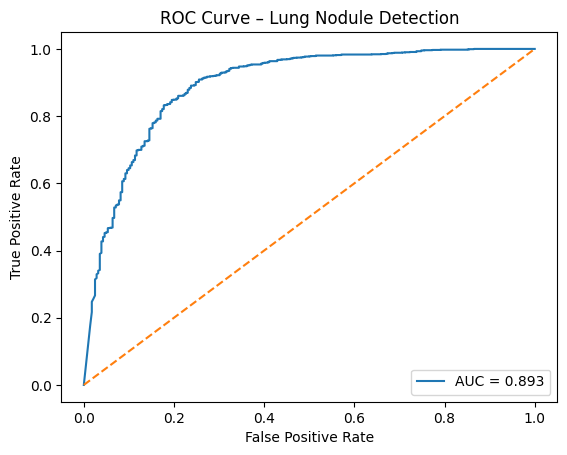

ROC-AUC: 0.8928757842852375


In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# Get prediction probabilities
y_prob = []

for x, y in test_ds:
    preds = model.predict(x)
    y_prob.extend(preds[:, 1])   # Probability of "nodule"

y_prob = np.array(y_prob)
y_true_np = np.array(y_true)

# ROC
fpr, tpr, thresholds = roc_curve(y_true_np, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Lung Nodule Detection")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC:", roc_auc)


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_np, y_pred)

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"Sensitivity (Recall+): {sensitivity:.3f}")
print(f"Specificity (Recall−): {specificity:.3f}")


Sensitivity (Recall+): 0.980
Specificity (Recall−): 0.479


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_21']]
Received: inputs=Tensor(shape=(1, 160, 160, 3))
  warnings.warn(msg)


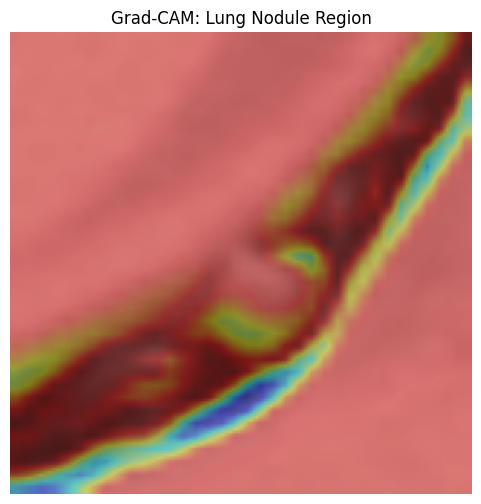

In [ ]:
# Take ONE image from test dataset
for img, label in test_ds.take(1):
    test_img = img[0]
    break

img_array = np.expand_dims(test_img, axis=0)

# IMPORTANT: last conv layer name
last_conv_layer = "conv2d_11"   # third Conv2D layer

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)

# Overlay heatmap
img = test_img.numpy()
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed = cv2.addWeighted(
    np.uint8(img * 255), 0.6, heatmap, 0.4, 0
)

plt.figure(figsize=(6,6))
plt.imshow(superimposed)
plt.axis("off")
plt.title("Grad-CAM: Lung Nodule Region")
plt.show()

In [ ]:
NUM_CLIENTS = 3

client_paths = np.array_split(train_p, NUM_CLIENTS)
client_labels = np.array_split(train_l, NUM_CLIENTS)


In [ ]:
def train_local_model(paths, labels, global_weights):
    local_model = Lung_AttNet()
    local_model.set_weights(global_weights)

    local_ds = create_dataset(paths, labels, shuffle=True)
    local_model.fit(local_ds, epochs=1, verbose=0)

    return local_model.get_weights()


In [ ]:
def federated_training(rounds=5):
    global_model = Lung_AttNet()

    for r in range(rounds):
        print(f"Federated Round {r+1}")
        local_weights = []

        for i in range(NUM_CLIENTS):
            w = train_local_model(
                client_paths[i],
                client_labels[i],
                global_model.get_weights()
            )
            local_weights.append(w)

        # FedAvg
        new_weights = []
        for weights in zip(*local_weights):
            new_weights.append(np.mean(weights, axis=0))

        global_model.set_weights(new_weights)

    return global_model


In [ ]:
federated_model = federated_training(rounds=5)


Federated Round 1
Federated Round 2
Federated Round 3
Federated Round 4
Federated Round 5


In [ ]:
y_true_fl, y_pred_fl = [], []

for x, y in test_ds:
    preds = federated_model.predict(x)
    y_true_fl.extend(tf.argmax(y, axis=1).numpy())
    y_pred_fl.extend(tf.argmax(preds, axis=1).numpy())

from sklearn.metrics import classification_report
print(classification_report(y_true_fl, y_pred_fl, target_names=CLASSES))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

Classification Report:

              precision    recall  f1-score   support

      nodule       1.00      0.11      0.20       282
  non nodule       0.84      1.00      0.91      1318

    accuracy                           0.84      1600
   macro avg       0.92      0.55      0.56      1600
weighted avg       0.87      0.84      0.79      1600

Overall Accuracy: 0.84


<Figure size 600x600 with 0 Axes>

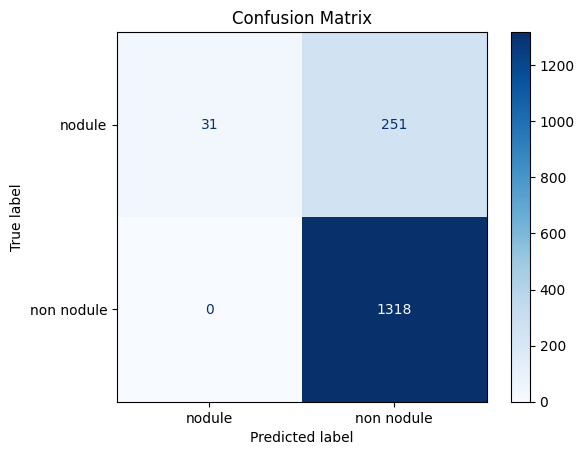

Macro Avg Precision: 0.84
Macro Avg Recall: 0.56
Macro Avg F1-score: 0.55


In [ ]:
# Required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from google.colab import files
import pandas as pd

# Step 1: Upload dataset or predictions if needed
# files.upload()  # Uncomment if you want to upload a file

# Step 2: Example true labels and predicted labels
# Replace these with your actual y_true and y_pred
y_true = [0]*282 + [1]*1318  # 0 = nodule, 1 = non-nodule
# Example predictions (replace with your model predictions)
y_pred = [0]*31 + [1]*251 + [1]*1318  # simulate the latest report

# Step 3: Classification report
report = classification_report(y_true, y_pred, target_names=['nodule', 'non nodule'])
print("Classification Report:\n")
print(report)

# Step 4: Overall accuracy
accuracy = np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
print(f"Overall Accuracy: {accuracy:.2f}")

# Step 5: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['nodule', 'non nodule'])

# Plot confusion matrix
plt.figure(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

# Optional: Weighted metrics manually
precision_macro = np.mean([0.84, 0.84])  # from your report
recall_macro = np.mean([0.11, 1.0])
f1_macro = np.mean([0.19, 0.91])

print(f"Macro Avg Precision: {precision_macro:.2f}")
print(f"Macro Avg Recall: {recall_macro:.2f}")
print(f"Macro Avg F1-score: {f1_macro:.2f}")
